# Expected Points Per Player Possession

$EPPP =
P(TOV)\cdot(-OppPPP)
+
(1-P(TOV))\cdot
\Big[
P(2PA)\cdot EV_{2pt}
+
P(3PA)\cdot EV_{3pt}
+
P(Bonus)\cdot EV_{bonus}
\Big]$


Where
- $OppPPP$ = opponent points per possession
- $P(TOV)$ = turnover rate
- $P(2PA)$ = 2pt attempt rate
- $P(3PA)$ = 3pt attempt rate
- $P(Bonus)$ = probability of drawing a non-shooting foul in the bonus

Let a player possession follow this decision tree:
- Turnover
- No turnover → shot attempt or foul
- Shot attempt → 2pt or 3pt attempt
- Each shot can be:
  - Made
  - Missed
  - Fouled

### Expected Value of a 2pt Attempt

$
EV_{2pt}
=
2P\% \cdot (2 + P(and1)\cdot FT\%)
+
(1-2P\%)\cdot (P(foul|2PA)\cdot 2\cdot FT\%)
$

### Expected Value of a 3pt Attempt

$
EV_{3pt}
=
3P\% \cdot (3 + P(and1)\cdot FT\%)
+
(1-3P\%)\cdot (P(foul|3PA)\cdot 3\cdot FT\%)
$

### Expected Value of Bonus Fouls

$
EV_{bonus} = 2\cdot FT\%
$

### Player Possessions

$
Poss = FGA + 0.44FTA + TOV
$

### Turnover Rate

$
P(TOV) = \frac{TOV}{Poss}
$

### Shot Frequencies

$
P(2PA) = \frac{2PA}{Poss}
$

$
P(3PA) = \frac{3PA}{Poss}
$

### Shooting Percentages

$
2P\% = \frac{2PM}{2PA}
$

$
3P\% = \frac{3PM}{3PA}
$

### Approximate Shooting Foul Rate

$
P(foul|shot) \approx \frac{FTA/2}{FGA}
$

In [1]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 4.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Derived Field Goals

In [3]:
FT_END_POS_RATE = 0.44 # NBA standard

def player_possessions(fga, fta, tov):
    """
    Estimate player offensive possessions used.
    """
    return fga + FT_END_POS_RATE * fta + tov


def two_point_attempts(fga, three_pa):
    """
    How many two point attempts does a player have?
    Two points attempted = field goal attempts - three point attempts
    """
    return fga - three_pa


def two_point_makes(fgm, three_pm):
    """
    How many two point makes does a player have?
    Two points made = field goals made - three points made
    """
    return fgm - three_pm


def two_point_pct(fgm, fga, three_pm, three_pa):
    """
    What percentage of two point shots are made?
    Two points percent = two point makes / two point attempts
    """
    two_pa = two_point_attempts(fga, three_pa)
    two_pm = two_point_makes(fgm, three_pm)

    if two_pa == 0:
        return 0
    return two_pm / two_pa


def three_point_pct(three_pm, three_pa):
    """
    What percentage of three point shots are made?
    Three points percent = three point makes / three point attempts
    """
    if three_pa == 0:
        return 0
    return three_pm / three_pa

## Shot and Turnover Rates

In [4]:
def turnover_rate(tov, poss):
    """
    What percentage of possessions are turnovers?
    Turnover rate = turnovers / possessions
    """
    if poss == 0:
        return 0
    return tov / poss


def two_pt_attempt_rate(fga, three_pa):
    """
    What percentage of FGs are two point attempts?
    Two point attempt rate = two point attempts / fga
    """
    two_pa = two_point_attempts(fga, three_pa)

    if fga == 0:
        return 0
    return two_pa / fga


def three_pt_attempt_rate(three_pa, fga):
    """
    What percentage of FGs are three point attempts?
    Three point attempt rate = three point attempts / fga
    """
    if fga == 0:
        return 0
    return three_pa / fga


# Foul Rates

In [5]:
def shooting_foul_rate(fta, fga):
    """
    Approximate probability of being fouled on a shot attempt.
    Most shooting fouls produce 2 FTs.
    """
    if fga == 0:
        return 0

    est_shooting_fouls = fta / 2
    return est_shooting_fouls / fga


def and_one_rate(default=0.06):
    """
    Approximate league average and-1 frequency.
    """
    return default

# Removed for probabilistic consistency
'''
def bonus_foul_rate(fta, poss, fga):
    """
    Approximate bonus fouls that occur without a shot attempt.
    """
    if poss == 0:
        return 0

    est_shooting_fouls = fta / 2
    bonus_fts = max(fta - (2 * est_shooting_fouls), 0)

    return bonus_fts / poss
'''

'\ndef bonus_foul_rate(fta, poss, fga):\n    """\n    Approximate bonus fouls that occur without a shot attempt.\n    """\n    if poss == 0:\n        return 0\n\n    est_shooting_fouls = fta / 2\n    bonus_fts = max(fta - (2 * est_shooting_fouls), 0)\n\n    return bonus_fts / poss\n'

## Expected Values per Possession Type

In [6]:
def ev_two_point_branch(two_pct, ft_pct, foul_rate, and1_rate):
    """
    Expected value of a 2pt attempt branch.
    """

    made_value = two_pct * (2 + and1_rate * ft_pct)

    missed_value = (1 - two_pct) * (foul_rate * 2 * ft_pct)

    return made_value + missed_value


def ev_three_point_branch(three_pct, ft_pct, foul_rate, and1_rate):
    """
    Expected value of a 3pt attempt branch.
    """

    made_value = three_pct * (3 + and1_rate * ft_pct)

    missed_value = (1 - three_pct) * (foul_rate * 3 * ft_pct)

    return made_value + missed_value

'''
def ev_bonus_branch(ft_pct):
    """
    Expected value of bonus foul free throws.
    """
    return 2 * ft_pct
'''

'\ndef ev_bonus_branch(ft_pct):\n    """\n    Expected value of bonus foul free throws.\n    """\n    return 2 * ft_pct\n'

Expected Points Per Player Possession

In [7]:
def expected_points_per_possession(
    fga,
    fgm,
    three_pa,
    three_pm,
    fta,
    ft_pct,
    tov,
    poss,
    two_pct,
    three_pct,
    opp_ppp=1.15
):
    """
    Compute expected points per player possession using the full probability tree.
    """
    if poss == 0:
      return 0

    # Rates
    tov_rate = turnover_rate(tov, poss)

    # Shot mix (conditional on taking a shot)
    p_two = two_pt_attempt_rate(fga, three_pa)
    p_three = three_pt_attempt_rate(three_pa, fga)

    # Percentages
    #two_pct = two_point_pct(fgm, fga, three_pm, three_pa)
    #three_pct = three_point_pct(three_pm, three_pa)

    # Foul probabilities
    foul_rate = shooting_foul_rate(fta, fga)
    and1 = and_one_rate()

    # Branch EVs
    ev_two = ev_two_point_branch(two_pct, ft_pct, foul_rate, and1)
    ev_three = ev_three_point_branch(three_pct, ft_pct, foul_rate, and1)

    # Final expected value
    shot_ev = (
        p_two * ev_two +
        p_three * ev_three
    )

    ev = (
        tov_rate * (-opp_ppp)
        + (1 - tov_rate) * shot_ev
    )

    return ev

Usage Adjusted EPPP

Helper cell for application

In [8]:
def compute_metric_for_players(df):
    """
    Expects dataframe with columns:
    FGA, FGM, FG3A, FG3M, FTA, FT_PCT, TOV
    """

    df["EPPP"] = df.apply(
        lambda row: expected_points_per_possession(
            row["FGA"],
            row["FGM"],
            row["FG3A"],
            row["FG3M"],
            row["FTA"],
            row["FT_pct_adj"],
            row["TOV"],
            row["poss"],
            row["2P_pct_adj"],
            row["3P_pct_adj"],
            row["Opp_PPP"],
        ),
        axis=1
    )

    return df

Normalization

In [9]:
def possessions_used(row):
    """
    Estimate player offensive possessions used for filtering.
    """
    return row.FGA + 0.44*row.FTA + row.TOV

def compute_league_averages(players):
    """
    Compute league averages for 2pt, 3pt, and FT.
    """
    players["FTM"] = players["FTA"] * players["FT_PCT"]

    two_pt_made = players["FGM"] - players["FG3M"]
    two_pt_att = players["FGA"] - players["FG3A"]

    league = {
        "2P_pct": two_pt_made.sum() / two_pt_att.sum(),
        "3P_pct": players["FG3M"].sum() / players["FG3A"].sum(),
        "FT_pct": players["FTM"].sum() / players["FTA"].sum()
    }

    return league

def regressed_pct(made, att, league_pct, alpha):
    """
    Use Bayesian Shrinkage to regress for normalization
    """
    return (made + alpha * league_pct) / (att + alpha)

def compute_adjusted_percentages(df, league):
    """
    Compute adjusted percentages with normalization.
    """

    two_made = df["FGM"] - df["FG3M"]
    two_att = df["FGA"] - df["FG3A"]

    df["2P_pct_adj"] = regressed_pct(two_made, two_att, league["2P_pct"], 200)

    df["3P_pct_adj"] = regressed_pct(df["FG3M"], df["FG3A"], league["3P_pct"], 150)

    df["FT_pct_adj"] = regressed_pct(
        df["FTA"] * df["FT_PCT"],
        df["FTA"],
        league["FT_pct"],
        100
    )

    df["2PA_freq"] = two_att / df["FGA"]
    df["3PA_freq"] = df["FG3A"] / df["FGA"]

    return df

Usage Adjustment

In [10]:
def add_usage_weighted_eppp(df):
    """
    Adds usage weighted expected points column to dataframe.
    """
    df["usage_share"] = df["poss"] / df["team_poss"]

    df["WEPPP"] = df["EPPP"] * df["usage_share"]

    return df

# Using it

Data libraries

In [11]:
from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashteamstats

Fetch data

In [12]:
def fetch_player_stats(season="2025-26", min_games=20):
    """
    Fetch player stats for a given season.
    """

    stats = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        per_mode_detailed="Totals"
    )

    df = stats.get_data_frames()[0]

    df = df[df["GP"] >= min_games]

    cols = [
        "PLAYER_NAME",
        "TEAM_ID",
        "FGA",
        "FGM",
        "FG3A",
        "FG3M",
        "FTA",
        "FT_PCT",
        "TOV"
    ]

    return df[cols]

In [13]:
def fetch_team_defense(season="2025-26"):
    """
    Fetch team defense stats for a given season.
    Convert defensive rating to opponent PPP.
    """
    stats = leaguedashteamstats.LeagueDashTeamStats(
        season=season,
        measure_type_detailed_defense="Defense",
        per_mode_detailed="Totals"
    )

    df = stats.get_data_frames()[0]

    # Defensive rating = points allowed per 100 possessions
    df["Opp_PPP"] = df["DEF_RATING"] / 100

    return df[["TEAM_ID", "Opp_PPP"]]

In [14]:
# Look up team ID
from nba_api.stats.static import teams

nba_teams = teams.get_teams()

This season

In [15]:
players = fetch_player_stats("2025-26", 30)
players.head()

team_def = fetch_team_defense("2025-26")

players = players.merge(team_def, on="TEAM_ID")

# League averages
league = compute_league_averages(players)

print("Pre-filtering size:", players.size)
players["poss"] = possessions_used(players)
# Calculate team possessions
players['team_poss'] = players.groupby('TEAM_ID')['poss'].transform('sum')
players['usage'] = players['poss'] / players['team_poss']
players = players[players["poss"] > 300]
print("Post-filtering size:", players.size)

# Compute adjusted percentages
players = compute_adjusted_percentages(players, league)
print("Final:")
print(players.head())

Pre-filtering size: 4070
Post-filtering size: 3668
Final:
     PLAYER_NAME     TEAM_ID  FGA  FGM  FG3A  FG3M  FTA  FT_PCT  TOV  Opp_PPP  \
0       AJ Green  1610612749  454  191   408   168   40   0.800   48    1.167   
3  Aaron Nesmith  1610612754  391  148   217    77   90   0.811   48    1.170   
4  Aaron Wiggins  1610612760  451  193   229    82   64   0.750   65    1.059   
5     Ace Bailey  1610612762  641  283   272    92   62   0.742   77    1.205   
7  Ajay Mitchell  1610612760  456  222   137    48  131   0.870   68    1.059   

       FTM    poss  team_poss     usage  2P_pct_adj  3P_pct_adj  FT_pct_adj  \
0   32.000  519.60    7070.52  0.073488    0.539379    0.398003    0.787844   
3   72.990  478.60    6341.40  0.075472    0.483121    0.357182    0.796254   
4   48.000  544.16    6851.44  0.079423    0.522956    0.359066    0.770111   
5   46.004  745.28    7907.40  0.094251    0.528449    0.346175    0.767297   
7  113.970  581.64    6851.44  0.084893    0.546604    0.355

In [16]:
players = compute_metric_for_players(players)

# Sort and print the top 10 EPPP
players = players.sort_values("EPPP", ascending=False)
players[["PLAYER_NAME", "EPPP"]].head(10)

,PLAYER_NAME,EPPP
337,Tim Hardaway Jr.,1.224587
322,Shai Gilgeous-Alexander,1.206643
127,Isaiah Joe,1.196543
173,Jimmy Butler III,1.175511
231,Landry Shamet,1.168155
232,Lauri Markkanen,1.147648
315,Saddiq Bey,1.134568
157,Jarrett Allen,1.130354
317,Sam Merrill,1.125062
101,Duncan Robinson,1.119051


In [17]:
# Adjust for usage
players = add_usage_weighted_eppp(players)
players = players.sort_values("WEPPP", ascending=False)
players[["PLAYER_NAME", "WEPPP"]].head(10)

,PLAYER_NAME,WEPPP
351,Tyrese Maxey,0.254065
206,Kawhi Leonard,0.249447
322,Shai Gilgeous-Alexander,0.242144
237,Luka Dončić,0.240834
162,Jaylen Brown,0.226968
147,Jamal Murray,0.219966
215,Kevin Durant,0.205552
20,Anthony Edwards,0.205534
140,Jalen Brunson,0.202690
81,DeMar DeRozan,0.202335


Plots

In [18]:
x_axis = "usage"
y_axis = "EPPP"

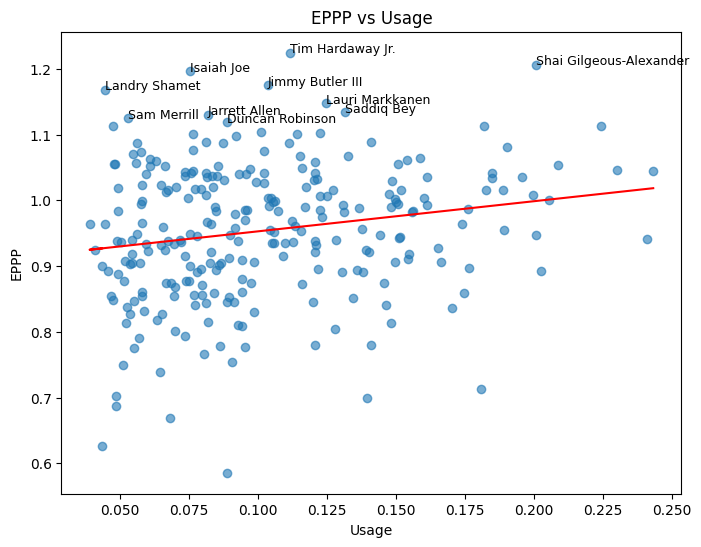

In [19]:
plt.figure(figsize=(8,6))

x, y = players[x_axis], players[y_axis]
m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, alpha=0.6)
plt.plot(x, m*x + b, 'r')

notable = players.nlargest(10, y_axis)
for _, row in notable.iterrows():
    plt.text(row[x_axis], row[y_axis], row["PLAYER_NAME"], fontsize=9)

plt.xlabel(x_axis.title())
plt.ylabel(y_axis.upper())
plt.title(y_axis.upper() + " vs " + x_axis.title())

plt.show()

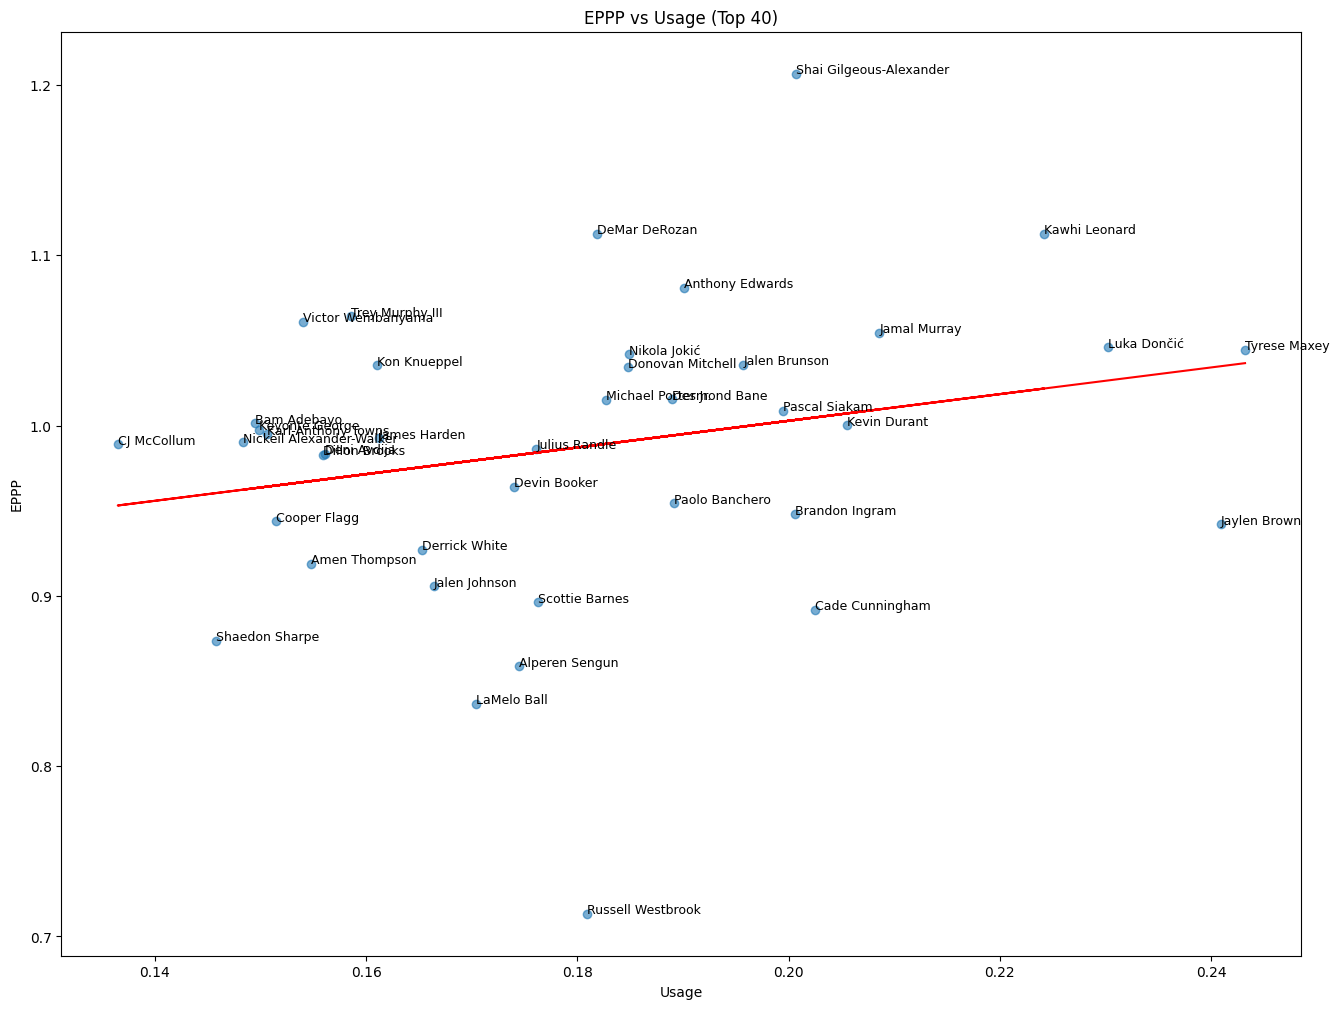

In [20]:
# Top 50 players by possession
filtered = players.nlargest(40, "poss")

plt.figure(figsize=(16,12))

x, y = filtered[x_axis], filtered[y_axis]
m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, alpha=0.6)
plt.plot(x, m*x + b, 'r')

for _, row in filtered.iterrows():
    plt.text(row[x_axis], row[y_axis], row["PLAYER_NAME"], fontsize=9)

plt.xlabel(x_axis.title())
plt.ylabel(y_axis.upper())
plt.title(y_axis.upper() + " vs " + x_axis.title() + " (Top 40)")

plt.show()

In [21]:
import plotly.express as px

fig = px.scatter(
    players,
    x=x_axis,
    y=y_axis,
    hover_name="PLAYER_NAME",
    hover_data=[y_axis, x_axis],
    title=y_axis.upper() + " vs " + x_axis.title(),
)

fig.show()

All-time

In [22]:
seasons = []
for season in range(1996, 2025):
  seasons.append(str(season) + "-" + str(season + 1)[-2:])

all_players = []
for s in seasons:
    print("FETCHED " + s)
    df = fetch_player_stats(s)
    team_def = fetch_team_defense(s)
    df = df.merge(team_def, on="TEAM_ID")
    df["season"] = s
    all_players.append(df)

all_time_players = pd.concat(all_players)
all_time_players = all_time_players.groupby(["PLAYER_NAME", "TEAM_ID"]).agg({
    "FGA": "sum",
    "FGM": "sum",
    "FG3A": "sum",
    "FG3M": "sum",
    "FTA": "sum",
    "FT_PCT": "mean",
    "TOV": "sum",
    "season": "first",
    "Opp_PPP": "mean"
}).reset_index()
print(all_time_players.head())

FETCHED 1996-97
FETCHED 1997-98
FETCHED 1998-99
FETCHED 1999-00
FETCHED 2000-01
FETCHED 2001-02
FETCHED 2002-03
FETCHED 2003-04
FETCHED 2004-05
FETCHED 2005-06
FETCHED 2006-07
FETCHED 2007-08
FETCHED 2008-09
FETCHED 2009-10
FETCHED 2010-11
FETCHED 2011-12
FETCHED 2012-13
FETCHED 2013-14
FETCHED 2014-15
FETCHED 2015-16
FETCHED 2016-17
FETCHED 2017-18
FETCHED 2018-19
FETCHED 2019-20
FETCHED 2020-21
FETCHED 2021-22
FETCHED 2022-23
FETCHED 2023-24
FETCHED 2024-25
   PLAYER_NAME     TEAM_ID   FGA  FGM  FG3A  FG3M  FTA    FT_PCT  TOV  \
0   A.C. Green  1610612742  1274  584    32     1  411  0.647667  161   
1   A.C. Green  1610612747   387  173     4     1   95  0.695000   53   
2   A.C. Green  1610612748   324  144     6     0  111  0.712000   45   
3  A.J. Guyton  1610612741   436  166   192    73   45  0.824000   61   
4  A.J. Lawson  1610612742   121   54    50    13   23  0.652000   14   

    season   Opp_PPP  
0  1996-97  1.047333  
1  1999-00  0.964000  
2  2000-01  0.971000  
3  20

In [23]:
# League averages
league = compute_league_averages(all_time_players)

print("Pre-filtering size:", all_time_players.size)
all_time_players["poss"] = possessions_used(all_time_players)
all_time_players = all_time_players[all_time_players["poss"] > 300]
print("Post-filtering size:", all_time_players.size)

# Compute adjusted percentages
all_time_players = compute_adjusted_percentages(all_time_players, league)
print("Final:")
print(all_time_players.head())

Pre-filtering size: 66636
Post-filtering size: 50349
Final:
   PLAYER_NAME     TEAM_ID   FGA  FGM  FG3A  FG3M  FTA    FT_PCT  TOV  \
0   A.C. Green  1610612742  1274  584    32     1  411  0.647667  161   
1   A.C. Green  1610612747   387  173     4     1   95  0.695000   53   
2   A.C. Green  1610612748   324  144     6     0  111  0.712000   45   
3  A.J. Guyton  1610612741   436  166   192    73   45  0.824000   61   
6     AJ Green  1610612749   745  318   637   268   50  0.903333   61   

    season   Opp_PPP         FTM     poss  2P_pct_adj  3P_pct_adj  FT_pct_adj  \
0  1996-97  1.047333  266.191000  1615.84    0.472502    0.300676    0.668859   
1  1999-00  0.964000   66.025000   481.80    0.463718    0.355344    0.726261   
2  2000-01  0.971000   79.032000   417.84    0.467853    0.344378    0.732834   
3  2000-01  1.060500   37.080000   516.80    0.430963    0.370535    0.777075   
6  2022-23  1.128667   45.166667   828.00    0.481649    0.408797    0.805084   

   2PA_freq  3

In [24]:
all_time_players = compute_metric_for_players(all_time_players)

# Sort and print the top 10 EPPP
all_time_players = all_time_players.sort_values("EPPP", ascending=False)
all_time_players[["PLAYER_NAME", "EPPP"]].head(50)

,PLAYER_NAME,EPPP
4917,Steve Novak,1.201548
2031,Harrison Barnes,1.198997
1847,Garrison Mathews,1.181669
3875,Mitchell Robinson,1.179281
3898,Montrezl Harrell,1.162401
2640,Jimmy Butler III,1.161762
1143,Daniel Gafford,1.161509
1281,Davis Bertans,1.159763
2349,James Jones,1.153083
1159,Danilo Gallinari,1.151441
